# Step 5 — Validate the saved ANN inverse-kinematics baseline

**Does the ANN put the robot hand near the requested target?** We now evaluate the frozen Step 4 model on its reserved test set. We keep the model, scalers, datasets, and Step 3.3 configuration policy unchanged.

```text
Target [x, y] in cm → input scaling → saved ANN
    → inverse output scaling → predicted joint angles in degrees
    → existing RobotArm2DOF.forward_kinematics → achieved [x, y]
    → distance from target in cm
```

Run from the repository root using the same Python environment as Step 4 (`requirements-ann.txt`). This notebook performs evaluation only; it neither trains nor optimizes the ANN. Once these test results have been reviewed, the test set is no longer an unseen source of evidence for any future model choices based on them.

## 5.1 Load the saved pipeline and verify the test split

The saved row indices are meaningful only for the exact dataset used in training. Check its SHA256 before indexing it, then check that the train/validation/test indices are integer, disjoint, and exhaustive. Load the fitted scalers without fitting them again. Only reserved test rows are passed through the ANN for the evaluation below.

Step 4's metadata remains a historical training record. Step 5 writes a separate evaluation report with source-file hashes so the result can be traced to the exact model, scalers, data, and robot definition.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
from pathlib import Path
from hashlib import sha256
import ast
import json
import platform
import importlib.metadata
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.neighbors import NearestNeighbors
from IPython.display import display

tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()
tf.config.threading.set_intra_op_parallelism_threads(2)
tf.config.threading.set_inter_op_parallelism_threads(2)

protected_paths = [Path("forward_kinematics.ipynb"), Path("ann_inverse_kinematics.ipynb"),
                   Path("data/robot_configurations.csv"), Path("data/robot_ik_training.csv"),
                   *sorted(Path("models").glob("*"))]
source_hashes = {path.as_posix(): sha256(path.read_bytes()).hexdigest()
                 for path in protected_paths if path.is_file()}
metadata = json.loads(Path("models/training_metadata.json").read_text(encoding="utf-8"))
data_path = Path("data/robot_ik_training.csv")
assert metadata["dataset"] == data_path.as_posix()
assert source_hashes[data_path.as_posix()] == metadata["dataset_sha256"], "Dataset hash mismatch."
data = pd.read_csv(data_path)
features, targets = metadata["features"], metadata["targets"]
assert features == ["x", "y"] and targets == ["theta1", "theta2"]
assert list(data.columns) == features + targets
assert data.shape == (39555, 4) and np.isfinite(data.to_numpy()).all()
assert not data[features].round(6).duplicated().any()

with np.load("models/split_indices.npz", allow_pickle=False) as saved_splits:
    assert set(saved_splits.files) == {"train", "validation", "test"}
    splits = {name: saved_splits[name].copy() for name in saved_splits.files}
for name, indices in splits.items():
    size_key = "training" if name == "train" else name
    assert indices.ndim == 1 and np.issubdtype(indices.dtype, np.integer)
    assert len(indices) == metadata["split_sizes"][size_key]
    assert len(np.unique(indices)) == len(indices)
    assert ((indices >= 0) & (indices < len(data))).all()
np.testing.assert_array_equal(np.sort(np.concatenate(list(splits.values()))), np.arange(len(data)))
test_indices = splits["test"]
test_data = data.iloc[test_indices].reset_index(drop=True)

input_scaler = joblib.load("models/input_scaler.joblib")
output_scaler = joblib.load("models/output_scaler.joblib")
assert list(input_scaler.feature_names_in_) == features
assert list(output_scaler.feature_names_in_) == targets
assert input_scaler.n_samples_seen_ == output_scaler.n_samples_seen_ == len(splits["train"])
model = tf.keras.models.load_model("models/ik_ann.keras", compile=False)
assert model.input_shape == (None, 2) and model.output_shape == (None, 2)
assert model.count_params() == metadata["trainable_parameters"]
print(f"Dataset hash and saved split verified. Evaluating {len(test_data):,} reserved test samples.")
print("Loaded frozen model and fitted scalers; no training or preprocessing fit.")

Dataset hash and saved split verified. Evaluating 3,956 reserved test samples.
Loaded frozen model and fitted scalers; no training or preprocessing fit.


## 5.2 Predict test angles and measure angle error

Convert the test positions to the input scale, predict scaled angles, then inverse-transform to degrees. Signed errors below mean **predicted minus true**; the summary uses their absolute values. We compare the selected joint labels directly, without modulo wrapping, because the robot's joints have bounded angle intervals.

Predictions remain unchanged: no clipping to joint limits, branch correction, or removal of difficult cases.

In [2]:
test_xy = test_data[features].to_numpy()
true_angles = test_data[targets].to_numpy()
scaled_test_xy = input_scaler.transform(test_data[features]).astype("float32")
predicted_scaled_angles = model.predict(scaled_test_xy, batch_size=32, verbose=0)
predicted_angles = output_scaler.inverse_transform(predicted_scaled_angles).astype("float64")
assert predicted_angles.shape == (len(test_data), 2) and np.isfinite(predicted_angles).all()
angle_errors = predicted_angles - true_angles
absolute_angle_errors = np.abs(angle_errors)
angle_summary = pd.DataFrame({
    "MAE (degrees)": absolute_angle_errors.mean(axis=0),
    "Median absolute error (degrees)": np.median(absolute_angle_errors, axis=0),
    "Maximum absolute error (degrees)": absolute_angle_errors.max(axis=0),
}, index=targets)
display(angle_summary.round(4))
overall_angle_mae = float(absolute_angle_errors.mean())
print(f"Overall angle MAE: {overall_angle_mae:.4f} degrees")

results = pd.DataFrame({
    "dataset_row_index": test_indices.astype("int64"),
    "x_target": test_xy[:, 0], "y_target": test_xy[:, 1],
    "theta1_true": true_angles[:, 0], "theta2_true": true_angles[:, 1],
    "theta1_pred": predicted_angles[:, 0], "theta2_pred": predicted_angles[:, 1],
    "theta1_error": angle_errors[:, 0], "theta2_error": angle_errors[:, 1],
})

,MAE (degrees),Median absolute error (degrees),Maximum absolute error (degrees)
theta1,1.9545,1.3211,133.3994
theta2,2.4038,1.2016,128.9900


Overall angle MAE: 2.1792 degrees


## 5.3 Close the loop with the existing forward kinematics

`RobotArm2DOF` currently lives in the mathematical notebook. To keep that implementation as the single source of truth, we read its class definition from that notebook instead of copying its equations. Python's syntax tree lets us load **only this class**: simulation, widgets, and data-generation cells are not executed. The mathematical notebook is unchanged.

First check that the test set's known angles reproduce the saved target positions within $10^{-9}$ cm. Then pass the predicted angles through that same method and measure

$$e=\sqrt{(x_{achieved}-x_{target})^2+(y_{achieved}-y_{target})^2}.$$

This distance is in **centimetres**. RMSE here is $\sqrt{\operatorname{mean}(e^2)}$, the root mean squared Euclidean distance, not an average over individual X/Y components.

The existing class does not enforce joint limits. We therefore report invalid angle predictions separately, while keeping every prediction in the position-error metrics. These FK positions describe where the unconstrained mathematical links would land, including invalid joint configurations.

In [3]:
robot_notebook = json.loads(Path("forward_kinematics.ipynb").read_text(encoding="utf-8"))
class_definitions = []
for cell in robot_notebook["cells"]:
    source = "".join(cell.get("source", []))
    if cell["cell_type"] == "code" and "class RobotArm2DOF" in source:
        class_definitions.extend(node for node in ast.parse(source).body
                                 if isinstance(node, ast.ClassDef) and node.name == "RobotArm2DOF")
assert len(class_definitions) == 1, "Expected one validated RobotArm2DOF definition."
class_module = ast.Module(body=class_definitions, type_ignores=[])
robot_namespace = {"np": np}
exec(compile(class_module, "forward_kinematics.ipynb:RobotArm2DOF", "exec"), robot_namespace)
robot = robot_namespace["RobotArm2DOF"](10, 10)

In [4]:
_, _, reference_xy = robot.forward_kinematics(true_angles[:, 0], true_angles[:, 1])
reference_error = np.linalg.norm(np.column_stack(reference_xy) - test_xy, axis=1)
assert reference_error.max() <= 1e-9
_, _, predicted_xy = robot.forward_kinematics(predicted_angles[:, 0], predicted_angles[:, 1])
achieved_xy = np.column_stack(predicted_xy)
assert achieved_xy.shape == test_xy.shape and np.isfinite(achieved_xy).all()
position_errors = np.linalg.norm(achieved_xy - test_xy, axis=1)
results["x_pred"], results["y_pred"] = achieved_xy[:, 0], achieved_xy[:, 1]
results["position_error_cm"] = position_errors

theta1_valid = (predicted_angles[:, 0] >= -90) & (predicted_angles[:, 0] <= 180)
theta2_valid = (predicted_angles[:, 1] >= -120) & (predicted_angles[:, 1] <= 120)
valid_joints = theta1_valid & theta2_valid
results["within_joint_limits"] = valid_joints
position_summary = {
    "mean_cm": float(position_errors.mean()), "median_cm": float(np.median(position_errors)),
    "rmse_cm": float(np.sqrt(np.mean(position_errors ** 2))),
    "p90_cm": float(np.percentile(position_errors, 90)),
    "p95_cm": float(np.percentile(position_errors, 95)), "max_cm": float(position_errors.max()),
}
display(pd.Series(position_summary, name="Cartesian position error (cm)").round(4))
print(f"True-angle FK reconstruction maximum error: {reference_error.max():.3e} cm")
print(f"Predictions outside theta1 limits: {(~theta1_valid).sum():,}")
print(f"Predictions outside theta2 limits: {(~theta2_valid).sum():,}")
print(f"Predictions outside either joint limit: {(~valid_joints).sum():,} / {len(results):,}")

mean_cm       0.4942
median_cm     0.3460
rmse_cm       1.3870
p90_cm        0.7780
p95_cm        0.9881
max_cm       32.7641
Name: Cartesian position error (cm), dtype: float64

True-angle FK reconstruction maximum error: 0.000e+00 cm
Predictions outside theta1 limits: 15
Predictions outside theta2 limits: 45
Predictions outside either joint limit: 56 / 3,956


## 5.4 Distribution of Cartesian error

All test samples appear in this histogram, including large errors. Reference lines show the mean, median, and 95th percentile. A small median with a larger mean indicates that a minority of large misses pull the average upward.

The count axis is logarithmic so rare large misses remain visible alongside the many small errors. Each tick increases the count by a factor of ten.

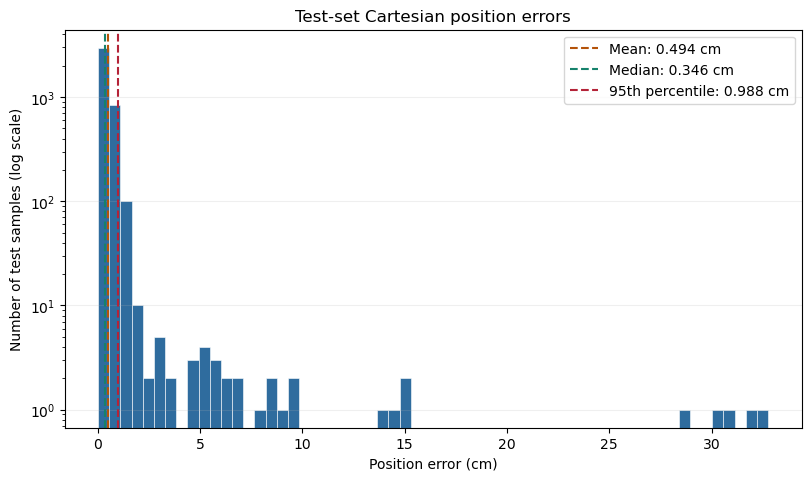

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.7), layout="constrained")
ax.hist(position_errors, bins=60, color="#2f6c9e", edgecolor="white", linewidth=0.4)
for key, label, colour in [("mean_cm", "Mean", "#b45309"),
                           ("median_cm", "Median", "#16826c"), ("p95_cm", "95th percentile", "#b42338")]:
    value = position_summary[key]
    ax.axvline(value, color=colour, linestyle="--", label=f"{label}: {value:.3f} cm")
ax.set(title="Test-set Cartesian position errors", xlabel="Position error (cm)", ylabel="Number of test samples (log scale)")
ax.set_yscale("log")
ax.grid(axis="y", alpha=0.2)
ax.legend()
plt.show()

## 5.5 Target workspace versus achieved workspace

The left panel shows the requested test targets. The right panel shows the endpoints produced by ANN-predicted angles passed through the existing FK model. Equal scales preserve the robot geometry. Both panels contain the same number of samples; there are no connecting lines or filtered cases.

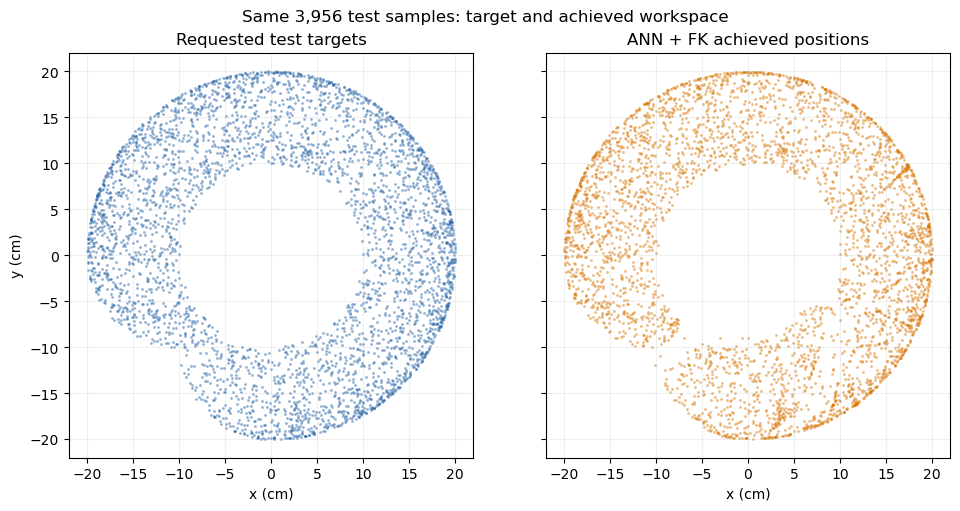

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True, layout="constrained")
for ax, xy, title, colour in zip(axes, [test_xy, achieved_xy],
    ["Requested test targets", "ANN + FK achieved positions"], ["#2563a6", "#d97706"]):
    ax.scatter(xy[:, 0], xy[:, 1], s=4, alpha=0.5, color=colour, linewidths=0)
    ax.set(title=title, xlabel="x (cm)", xlim=(-22, 22), ylim=(-22, 22), aspect="equal")
    ax.grid(alpha=0.2)
axes[0].set_ylabel("y (cm)")
fig.suptitle(f"Same {len(results):,} test samples: target and achieved workspace")
plt.show()

## 5.6 Where are the position errors?

Colour the **target** positions by Cartesian error. The colour scale saturates at the 95th percentile so typical errors remain distinguishable; the colourbar's upper extension includes larger misses. All samples remain plotted. Rings identify the ten largest errors.

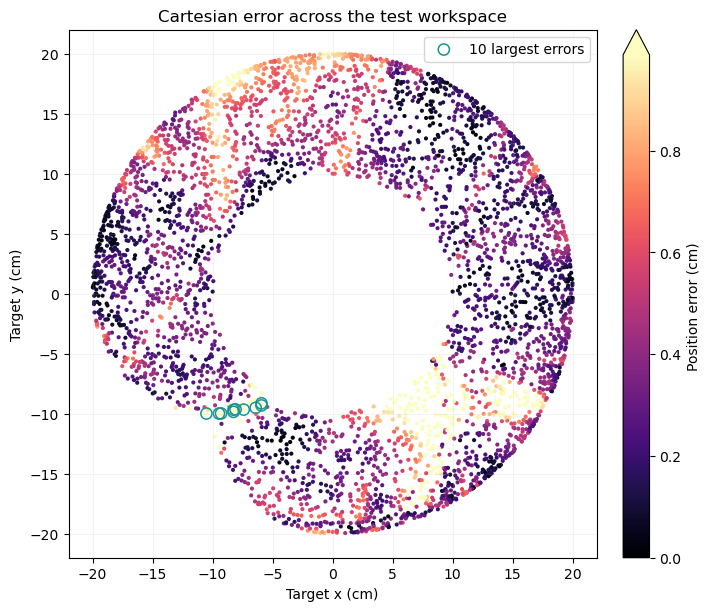

In [7]:
worst_indices = results.nlargest(10, "position_error_cm").index
fig, ax = plt.subplots(figsize=(7, 6), layout="constrained")
points = ax.scatter(test_xy[:, 0], test_xy[:, 1], c=position_errors, cmap="magma",
                    vmin=0, vmax=position_summary["p95_cm"], s=9, linewidths=0)
ax.scatter(test_xy[worst_indices, 0], test_xy[worst_indices, 1], facecolors="none",
           edgecolors="#149594", s=65, linewidths=1.1, label="10 largest errors")
fig.colorbar(points, ax=ax, extend="max", label="Position error (cm)")
ax.set(title="Cartesian error across the test workspace", xlabel="Target x (cm)", ylabel="Target y (cm)",
       xlim=(-22, 22), ylim=(-22, 22), aspect="equal")
ax.grid(alpha=0.15)
ax.legend(loc="upper right")
plt.show()

## 5.7 The ten worst predictions

These are the largest Euclidean misses on the reserved test set, ordered from worst downward. True angles are the Step 3.3 selected labels. Predicted angles and achieved positions are unmodified; the joint-limit flag distinguishes geometric error from configuration validity.

In [8]:
worst_columns = ["dataset_row_index", "x_target", "y_target", "theta1_true", "theta2_true",
                 "theta1_pred", "theta2_pred", "x_pred", "y_pred", "position_error_cm", "within_joint_limits"]
worst_samples = results.loc[worst_indices, worst_columns]
display(worst_samples.round(3).reset_index(drop=True))

,dataset_row_index,x_target,y_target,theta1_true,theta2_true,theta1_pred,theta2_pred,x_pred,y_pred,position_error_cm,within_joint_limits
0,10718,-8.264,-9.848,180.0,100.0,46.601,10.701,12.273,15.681,32.764,True
1,11466,-7.412,-9.659,180.0,105.0,63.389,12.481,6.921,18.638,31.720,True
2,9758,-9.302,-9.976,180.0,94.0,76.520,23.960,0.512,19.558,31.121,True
3,12730,-5.933,-9.135,180.0,114.0,66.272,10.955,6.235,18.907,30.569,True
4,9591,-9.477,-9.986,180.0,93.0,90.692,31.567,-5.458,18.456,28.724,True
5,10869,-8.090,-9.642,179.0,102.0,134.811,68.608,-16.224,3.120,15.133,True
6,12733,-5.931,-9.310,-66.0,-113.0,-24.882,-71.125,8.025,-14.153,14.773,True
7,10721,-8.262,-9.674,179.0,101.0,137.378,68.995,-16.318,2.330,14.456,True
8,12322,-6.415,-9.510,-69.0,-110.0,-27.151,-74.602,6.861,-14.354,14.132,True
9,8500,-10.523,-9.986,180.0,87.0,152.046,70.954,-16.147,-2.133,9.659,True


## 5.8 Explore the branch-selection boundary

Use only test positions and their **true selected theta2 signs**. For each non-straight target, find the nearest test target with the opposite sign. A short distance is a simple proxy for being near a region where the selected branch changes. Compare targets within **1 cm** of an opposite-sign sample with those farther away; this is a fixed descriptive threshold, not a tuning rule.

This is **sampled branch proximity, not exact distance to a mathematical discontinuity**. Sparse sampling can overestimate distance to a boundary. Opposite signs can also meet smoothly near a straight arm. To help interpret that distinction, we record the largest joint-angle label difference to the nearby opposite-sign sample. Straight labels are excluded from this proximity calculation and reported separately; they remain included in every overall test metric.

The nearest-neighbour search is only a geometric lookup of test labels, not a new IK model. See [scikit-learn NearestNeighbors](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.NearestNeighbors.html). Any association is observational and does not establish the cause of the ANN's errors.

,Group,Samples,Mean error (cm),Median error (cm),95th percentile (cm),Error > 1 cm (%)
0,Opposite branch within 1 cm,176,2.077,0.589,8.187,34.091
1,Opposite branch farther than 1 cm,3746,0.420,0.338,0.906,3.390
2,Straight (excluded from proxy),34,0.483,0.419,1.172,11.765


Worst targets and their nearest opposite-branch sample:


,dataset_row_index,position_error_cm,true_branch,opposite_branch_distance_cm,opposite_branch_joint_gap_degrees
0,10718,32.764,positive,0.945,257.0
1,11466,31.720,positive,1.002,257.0
2,9758,31.121,positive,0.381,265.0
3,12730,30.569,positive,0.175,246.0
4,9591,28.724,positive,0.481,265.0
5,10869,15.133,positive,1.044,256.0
6,12733,14.773,negative,0.175,246.0
7,10721,14.456,positive,1.071,264.0
8,12322,14.132,negative,0.523,248.0
9,8500,9.659,positive,1.438,265.0


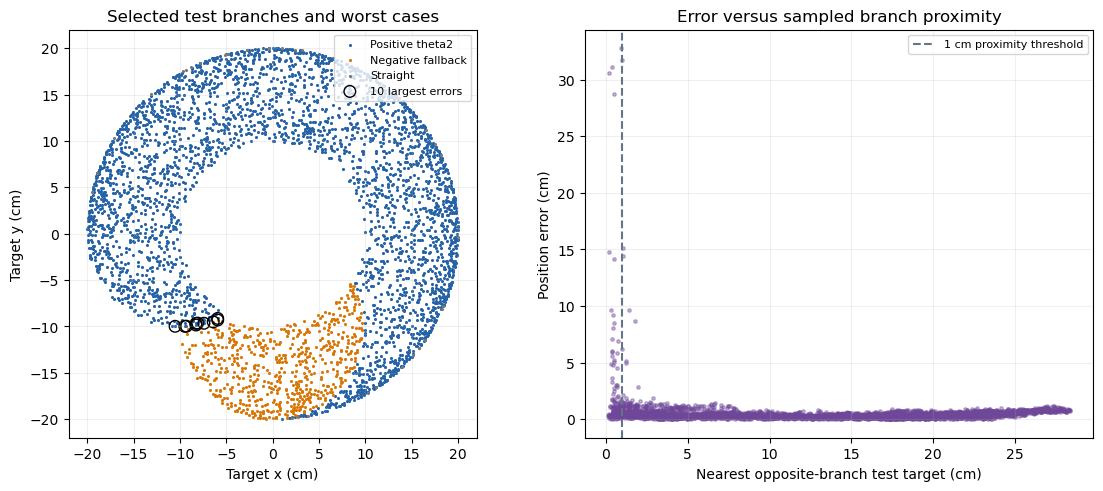

In [9]:
branch_sign = np.sign(true_angles[:, 1]).astype(int)
opposite_distance = np.full(len(results), np.nan)
opposite_joint_gap = np.full(len(results), np.nan)
for sign in [-1, 1]:
    current = np.flatnonzero(branch_sign == sign)
    opposite = np.flatnonzero(branch_sign == -sign)
    assert len(current) > 0 and len(opposite) > 0
    neighbours = NearestNeighbors(n_neighbors=1, metric="euclidean").fit(test_xy[opposite])
    distances, neighbour_indices = neighbours.kneighbors(test_xy[current])
    matched = opposite[neighbour_indices[:, 0]]
    opposite_distance[current] = distances[:, 0]
    opposite_joint_gap[current] = np.abs(true_angles[current] - true_angles[matched]).max(axis=1)
results["true_branch"] = np.where(branch_sign > 0, "positive", np.where(branch_sign < 0, "negative", "straight"))
results["opposite_branch_distance_cm"] = opposite_distance
results["opposite_branch_joint_gap_degrees"] = opposite_joint_gap
boundary_masks = {
    "Opposite branch within 1 cm": opposite_distance <= 1.0,
    "Opposite branch farther than 1 cm": opposite_distance > 1.0,
    "Straight (excluded from proxy)": branch_sign == 0,
}
assert sum(int(mask.sum()) for mask in boundary_masks.values()) == len(results)
boundary_rows = []
for name, mask in boundary_masks.items():
    errors = position_errors[mask]
    boundary_rows.append({"Group": name, "Samples": int(mask.sum()),
        "Mean error (cm)": float(errors.mean()), "Median error (cm)": float(np.median(errors)),
        "95th percentile (cm)": float(np.percentile(errors, 95)),
        "Error > 1 cm (%)": float(100 * (errors > 1).mean())})
boundary_summary = pd.DataFrame(boundary_rows)
display(boundary_summary.round(3))
print("Worst targets and their nearest opposite-branch sample:")
display(results.loc[worst_indices, ["dataset_row_index", "position_error_cm", "true_branch",
    "opposite_branch_distance_cm", "opposite_branch_joint_gap_degrees"]].round(3).reset_index(drop=True))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), layout="constrained")
for sign, name, colour in [(1, "Positive theta2", "#2563a6"), (-1, "Negative fallback", "#d97706"), (0, "Straight", "#777777")]:
    mask = branch_sign == sign
    axes[0].scatter(test_xy[mask, 0], test_xy[mask, 1], s=5, color=colour, linewidths=0, label=name)
axes[0].scatter(test_xy[worst_indices, 0], test_xy[worst_indices, 1], facecolors="none", edgecolors="black", s=70, label="10 largest errors")
axes[0].set(title="Selected test branches and worst cases", xlabel="Target x (cm)", ylabel="Target y (cm)",
            xlim=(-22, 22), ylim=(-22, 22), aspect="equal")
axes[0].legend(fontsize=8, loc="upper right")
non_straight = branch_sign != 0
axes[1].scatter(opposite_distance[non_straight], position_errors[non_straight], s=6, alpha=0.4, color="#6f4799")
axes[1].axvline(1, linestyle="--", color="#64748b", label="1 cm proximity threshold")
axes[1].set(title="Error versus sampled branch proximity", xlabel="Nearest opposite-branch test target (cm)",
            ylabel="Position error (cm)")
axes[1].legend(fontsize=8)
for ax in axes: ax.grid(alpha=0.2)
plt.show()

### What the boundary investigation shows

The largest misses cluster in the lower-left workspace near the change from the preferred positive branch to the negative fallback. The 176 non-straight test targets within 1 cm of an opposite-branch sample have **2.077 cm mean error**, compared with **0.420 cm** for the 3,746 farther targets. Errors exceed 1 cm for **34.09%** of the nearby group versus **3.39%** farther away. The 34 straight targets are excluded only from this proximity proxy.

Six of the ten worst cases fall inside the fixed 1 cm proximity threshold; all ten are within 1.44 cm of an opposite-branch test sample. Their maximum joint-label differences to those neighbouring samples are **246–265 degrees**, so these examples involve large label changes, not only the smooth meeting of branches at a straight arm. This is strong evidence of an association with the policy transition in this test set, although it does not prove that the policy is the only source of error.

The worst target is **(-8.264, -9.848) cm** with selected angles **(180, 100) degrees**. The ANN predicts approximately **(46.601, 10.701) degrees**, and FK places the endpoint at **(12.273, 15.681) cm**: a **32.764 cm** miss. Both predicted angles are inside their joint limits, so a joint-limit check alone would not catch this failure. A continuous network producing intermediate angles near a sharp label change is a plausible explanation; we have not changed the policy or model to test that explanation.


## 5.9 Practical accuracy thresholds

For each tolerance, report how many requested test positions are reached within that Euclidean distance. These are **geometric accuracy rates**, not a complete pick-and-place success measure. The final column additionally requires both predicted joint angles to satisfy their limits; neither column excludes any target from the denominator.

In [10]:
success_rows = []
for tolerance in [0.25, 0.5, 1.0, 2.0]:
    close = position_errors <= tolerance
    success_rows.append({"Tolerance (cm)": tolerance, "Samples within tolerance": int(close.sum()),
                        "Within tolerance (%)": float(100 * close.mean()),
                        "Within tolerance and joint limits (%)": float(100 * (close & valid_joints).mean())})
success_summary = pd.DataFrame(success_rows)
display(success_summary.round(3))

,Tolerance (cm),Samples within tolerance,Within tolerance (%),Within tolerance and joint limits (%)
0,0.25,1304,32.963,32.836
1,0.50,2781,70.298,70.096
2,1.00,3765,95.172,94.540
3,2.00,3916,98.989,97.750


## 5.10 Helpers for manual targets

`predict_angles(x, y)` accepts centimetres and returns predicted joint angles in degrees. `evaluate_target(x, y)` also uses the existing robot model to return the achieved position, distance error, and joint-limit flag. These helpers do not reject unreachable targets or repair predictions: they expose what this baseline predicts. They perform no training.

For later use in this notebook, run the pipeline-loading cell, the existing-class loading cell, and these helper definitions. Batched and single-target float32 inference may differ by tiny rounding amounts, so the checks use small numerical tolerances.

In [11]:
def predict_angles(x, y):
    """Return (theta1, theta2) in degrees for a target expressed in cm."""
    target = pd.DataFrame([[x, y]], columns=features, dtype=float)
    if not np.isfinite(target.to_numpy()).all():
        raise ValueError("Target coordinates must be finite numbers.")
    scaled_input = input_scaler.transform(target).astype("float32")
    scaled_angles = model(scaled_input, training=False).numpy()
    angles = output_scaler.inverse_transform(scaled_angles)[0]
    return float(angles[0]), float(angles[1])

def evaluate_target(x, y):
    """Predict angles and report the achieved endpoint and target distance."""
    theta1, theta2 = predict_angles(x, y)
    _, _, achieved = robot.forward_kinematics(theta1, theta2)
    return {"target_x": float(x), "target_y": float(y),
            "theta1": theta1, "theta2": theta2,
            "achieved_x": float(achieved[0]), "achieved_y": float(achieved[1]),
            "position_error_cm": float(np.hypot(achieved[0] - x, achieved[1] - y)),
            "within_joint_limits": -90 <= theta1 <= 180 and -120 <= theta2 <= 120}

In [12]:
# Check helper/batch agreement on reserved test samples only.
example_indices = np.linspace(0, len(test_data) - 1, 5, dtype=int)
for index in example_indices:
    example = evaluate_target(*test_xy[index])
    np.testing.assert_allclose([example["theta1"], example["theta2"]], predicted_angles[index], rtol=0, atol=1e-3)
    np.testing.assert_allclose([example["achieved_x"], example["achieved_y"]], achieved_xy[index], rtol=0, atol=1e-4)
try:
    predict_angles(np.nan, 0)
except ValueError:
    pass
else:
    raise AssertionError("Nonfinite targets must be rejected.")
print("Helper checks passed on five test targets; no data or predictions were corrected.")

Helper checks passed on five test targets; no data or predictions were corrected.


## 5.11 Five human-readable test examples

Take five evenly spaced entries in the saved, randomly ordered test split. The examples are chosen by index, not by prediction quality; the worst-case table remains available above.

In [13]:
for index in example_indices:
    example = evaluate_target(*test_xy[index])
    print(f"Test dataset row {test_indices[index]}:")
    print(f"  Target: x = {example['target_x']:.2f} cm, y = {example['target_y']:.2f} cm")
    print(f"  ANN prediction: theta1 = {example['theta1']:.2f} degrees, theta2 = {example['theta2']:.2f} degrees")
    print(f"  Forward kinematics: x = {example['achieved_x']:.2f} cm, y = {example['achieved_y']:.2f} cm")
    print(f"  Position error: {example['position_error_cm']:.4f} cm")
    print(f"  Both joint limits satisfied: {example['within_joint_limits']}\n")

Test dataset row 8668:
  Target: x = -10.36 cm, y = 1.36 cm
  ANN prediction: theta1 = 112.62 degrees, theta2 = 117.57 degrees
  Forward kinematics: x = -10.25 cm, y = 1.55 cm
  Position error: 0.2166 cm
  Both joint limits satisfied: True

Test dataset row 16106:
  Target: x = -1.93 cm, y = -12.16 cm
  ANN prediction: theta1 = -46.93 degrees, theta2 = -105.14 degrees
  Forward kinematics: x = -2.01 cm, y = -11.99 cm
  Position error: 0.1898 cm
  Both joint limits satisfied: True

Test dataset row 20753:
  Target: x = 3.39 cm, y = 14.11 cm
  ANN prediction: theta1 = 34.53 degrees, theta2 = 86.06 degrees
  Forward kinematics: x = 3.15 cm, y = 14.28 cm
  Position error: 0.2917 cm
  Both joint limits satisfied: True

Test dataset row 35156:
  Target: x = 15.99 cm, y = -8.68 cm
  ANN prediction: theta1 = -48.44 degrees, theta2 = 48.14 degrees
  Forward kinematics: x = 16.63 cm, y = -7.53 cm
  Position error: 1.3155 cm
  Both joint limits satisfied: True

Test dataset row 31104:
  Target: x

## Save the evaluation record

Save one row per reserved test target plus a compact summary. The report records dataset, model, scaler, and source hashes. Step 4's training metadata and all original artifacts stay unchanged. The CSV preserves the saved test order and original dataset row indices; angle errors are degrees and position errors are cm.

In [14]:
assert len(results) == len(test_indices) and results.dataset_row_index.is_unique
assert np.isfinite(results[["x_pred", "y_pred", "position_error_cm", "theta1_pred", "theta2_pred"]].to_numpy()).all()
for filename, expected_hash in source_hashes.items():
    assert sha256(Path(filename).read_bytes()).hexdigest() == expected_hash, f"Source changed: {filename}"
worst = results.loc[worst_indices[0]]
summary = {
    "test_samples": len(results), "source_sha256": source_hashes,
    "theta1_mae_degrees": float(absolute_angle_errors[:, 0].mean()),
    "theta2_mae_degrees": float(absolute_angle_errors[:, 1].mean()),
    "overall_angle_mae_degrees": overall_angle_mae,
    "angle_summary": angle_summary.to_dict(), "position_error": position_summary,
    "success_rates": success_rows, "joint_limit_violations": int((~valid_joints).sum()),
    "theta1_limit_violations": int((~theta1_valid).sum()), "theta2_limit_violations": int((~theta2_valid).sum()),
    "true_angle_fk_max_error_cm": float(reference_error.max()),
    "branch_proximity_threshold_cm": 1.0, "branch_proximity_summary": boundary_rows,
    "worst_10_within_branch_proximity": int((opposite_distance[worst_indices] <= 1).sum()),
    "worst_case": {"dataset_row_index": int(worst.dataset_row_index),
                   "x_target": float(worst.x_target), "y_target": float(worst.y_target),
                   "theta1_true": float(worst.theta1_true), "theta2_true": float(worst.theta2_true),
                   "theta1_pred": float(worst.theta1_pred), "theta2_pred": float(worst.theta2_pred),
                   "x_pred": float(worst.x_pred), "y_pred": float(worst.y_pred),
                   "position_error_cm": float(worst.position_error_cm),
                   "within_joint_limits": bool(worst.within_joint_limits)},
    "model_retrained": False, "policy_changed": False, "predictions_clipped": False,
    "evaluation_scope": "All reserved Step 4 test rows; helpers/examples use only test targets",
    "versions": {name: importlib.metadata.version(name) for name in
                 ["tensorflow", "keras", "numpy", "pandas", "scikit-learn", "joblib"]},
    "python": platform.python_version(),
}
evaluation_directory = Path("evaluation")
evaluation_directory.mkdir(exist_ok=True)
results.to_csv(evaluation_directory / "test_predictions.csv", index=False)
(evaluation_directory / "summary.json").write_text(json.dumps(summary, indent=2, allow_nan=False) + "\n", encoding="utf-8")
reloaded = pd.read_csv(evaluation_directory / "test_predictions.csv")
pd.testing.assert_frame_equal(reloaded, results, check_exact=False, atol=1e-10, rtol=0)
print("Evaluation saved; model, scalers, datasets, and existing notebooks unchanged.")
print(json.dumps({"test_samples": summary["test_samples"], "angle_mae_degrees": [summary["theta1_mae_degrees"], summary["theta2_mae_degrees"]],
                  "position_error_cm": position_summary, "success_rates": success_rows,
                  "joint_limit_violations": summary["joint_limit_violations"], "worst_case": summary["worst_case"]}, indent=2))

Evaluation saved; model, scalers, datasets, and existing notebooks unchanged.
{
  "test_samples": 3956,
  "angle_mae_degrees": [
    1.9545230201878223,
    2.4038270111690125
  ],
  "position_error_cm": {
    "mean_cm": 0.494219794615333,
    "median_cm": 0.3459520414140541,
    "rmse_cm": 1.3870202128204063,
    "p90_cm": 0.777957408447394,
    "p95_cm": 0.9881431152046354,
    "max_cm": 32.764087290180406
  },
  "success_rates": [
    {
      "Tolerance (cm)": 0.25,
      "Samples within tolerance": 1304,
      "Within tolerance (%)": 32.96258847320526,
      "Within tolerance and joint limits (%)": 32.836198179979775
    },
    {
      "Tolerance (cm)": 0.5,
      "Samples within tolerance": 2781,
      "Within tolerance (%)": 70.29828109201213,
      "Within tolerance and joint limits (%)": 70.09605662285136
    },
    {
      "Tolerance (cm)": 1.0,
      "Samples within tolerance": 3765,
      "Within tolerance (%)": 95.17189079878665,
      "Within tolerance and joint limits (%)

## Step 5 result and review checkpoint

On all **3,956 reserved test targets**, angle MAEs are **1.9545 degrees** for theta1 and **2.4038 degrees** for theta2. Cartesian error has **0.4942 cm mean**, **0.3460 cm median**, **0.7780 cm 90th percentile**, **0.9881 cm 95th percentile**, and **32.7641 cm maximum** (RMSE **1.3870 cm**).

The percentages within **0.25 / 0.5 / 1 / 2 cm** are **32.96% / 70.30% / 95.17% / 98.99%**. There are **56 predictions outside at least one joint limit**. Requiring both joint-limit validity and at most 1 cm error gives **94.54%** of all test targets. These are geometric measurements, not yet a full manipulation success test.

Most predictions are close, but the small group of large misses matters: average angle error alone hid severe endpoint failures near the branch transition. The original FK reproduces the test targets from their true angles with zero measured error, which supports using it to measure the ANN's misses. The model, scalers, datasets, and policy remain unchanged.

Review these results before choosing whether to improve the baseline or proceed to simulated box pickup. **No retraining, policy redesign, or box-pickup implementation has been performed.**
